# HW02

学号：20234080115  
姓名：李其隆

## 2 多层感知机

### 2.1 理论计算题

1. 若隐藏层没有非线性激活：

$$
h = W_1x + b_1,\quad o = W_2h + b_2
$$

代入可得：

$$
o = W_2(W_1x + b_1) + b_2 = (W_2W_1)x + (W_2b_1 + b_2)
$$

所以该网络等价于单层神经网络：

$$
W' = W_2W_1,\quad b' = W_2b_1 + b_2
$$

这说明如果没有非线性激活函数，多层线性变换仍然只是一个线性变换。

2. Sigmoid 与 tanh：

$$
\sigma(x)=\frac{1}{1+e^{-x}},\quad \sigma'(x)=\sigma(x)(1-\sigma(x))
$$

$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}},\quad \tanh'(x)=1-\tanh^2(x)
$$

### 2.2 编程题：从零实现单隐藏层 MLP

In [1]:
import gzip
import os
import struct
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(42)
np.random.seed(42)
torch.set_num_threads(min(4, os.cpu_count() or 1))

plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path("data/FashionMNIST/raw")
BASE_URLS = [
    "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/{name}.gz",
    "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/{name}.gz",
]

FILES = [
    "train-images-idx3-ubyte",
    "train-labels-idx1-ubyte",
    "t10k-images-idx3-ubyte",
    "t10k-labels-idx1-ubyte",
]


def ensure_fashion_mnist():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for name in FILES:
        raw_path = DATA_DIR / name
        gz_path = DATA_DIR / f"{name}.gz"
        if not raw_path.exists():
            if not gz_path.exists():
                last_error = None
                for pattern in BASE_URLS:
                    url = pattern.format(name=name)
                    try:
                        urllib.request.urlretrieve(url, gz_path)
                        break
                    except Exception as exc:
                        last_error = exc
                if not gz_path.exists():
                    raise RuntimeError(f"Could not download {name}: {last_error}")
            with gzip.open(gz_path, "rb") as fin, open(raw_path, "wb") as fout:
                fout.write(fin.read())


def read_idx_images(path):
    with open(path, "rb") as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows * cols).astype("float32") / 255.0


def read_idx_labels(path):
    with open(path, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels.astype("int64")


ensure_fashion_mnist()

X_train_all = torch.tensor(read_idx_images(DATA_DIR / "train-images-idx3-ubyte"))
y_train_all = torch.tensor(read_idx_labels(DATA_DIR / "train-labels-idx1-ubyte"))
X_test_all = torch.tensor(read_idx_images(DATA_DIR / "t10k-images-idx3-ubyte"))
y_test_all = torch.tensor(read_idx_labels(DATA_DIR / "t10k-labels-idx1-ubyte"))

train_n = 4000
val_n = 1000
X_train, y_train = X_train_all[:train_n], y_train_all[:train_n]
X_val, y_val = X_test_all[:val_n], y_test_all[:val_n]

print("train shape:", tuple(X_train.shape), "validation shape:", tuple(X_val.shape))
print("classes:", sorted(y_train.unique().tolist()))

train shape: (4000, 784) validation shape: (1000, 784)
classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [2]:
def relu(X):
    return torch.clamp(X, min=0)


def cross_entropy_with_softmax(logits, y):
    shifted = logits - logits.max(dim=1, keepdim=True).values
    log_probs = shifted - torch.log(torch.exp(shifted).sum(dim=1, keepdim=True))
    return -log_probs[torch.arange(y.shape[0]), y].mean()


def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()


def init_mlp(num_inputs=784, num_hiddens=128, num_outputs=10):
    W1 = torch.randn(num_inputs, num_hiddens) * 0.01
    b1 = torch.zeros(num_hiddens)
    W2 = torch.randn(num_hiddens, num_outputs) * 0.01
    b2 = torch.zeros(num_outputs)
    params = [W1, b1, W2, b2]
    for p in params:
        p.requires_grad_(True)
    return params


def net(X, params):
    W1, b1, W2, b2 = params
    H = relu(torch.matmul(X, W1) + b1)
    return torch.matmul(H, W2) + b2


def sgd(params, lr, batch_size, weight_decay=0.0):
    with torch.no_grad():
        for p in params:
            if p.grad is None:
                continue
            if weight_decay and p.ndim > 1:
                p *= (1 - lr * weight_decay)
            p -= lr * p.grad
            p.grad.zero_()


def batch_iter(X, y, batch_size, shuffle=True):
    indices = torch.randperm(len(X)) if shuffle else torch.arange(len(X))
    for i in range(0, len(X), batch_size):
        batch_idx = indices[i:i + batch_size]
        yield X[batch_idx], y[batch_idx]


params = init_mlp()
lr = 0.5
batch_size = 256
epochs = 3

for epoch in range(1, epochs + 1):
    train_loss_sum = 0.0
    seen = 0
    for Xb, yb in batch_iter(X_train, y_train, batch_size):
        logits = net(Xb, params)
        loss = cross_entropy_with_softmax(logits, yb)
        loss.backward()
        sgd(params, lr, batch_size)
        train_loss_sum += loss.item() * len(Xb)
        seen += len(Xb)
    with torch.no_grad():
        val_logits = net(X_val, params)
        val_loss = cross_entropy_with_softmax(val_logits, y_val).item()
        val_acc = accuracy(val_logits, y_val)
    print(f"epoch {epoch}: train_loss={train_loss_sum/seen:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

epoch 1: train_loss=1.9333, val_loss=2.1338, val_acc=0.2340
epoch 2: train_loss=1.6133, val_loss=1.1848, val_acc=0.5130
epoch 3: train_loss=1.1919, val_loss=1.0054, val_acc=0.6290


## 3 模型选择、权重衰减和丢弃法

### 3.1 理论计算题

1. 训练误差是在训练集上的误差，泛化误差是在未见过的数据上的期望误差。若训练误差极低而泛化误差很高，模型通常处于过拟合状态。可以通过减少模型容量、增加数据、加入权重衰减、使用 Dropout、早停等方式缓解。

2. K 折交叉验证步骤：

将训练数据平均分成 K 份；每次取其中 1 份作为验证集，其余 K-1 份作为训练集；重复 K 次，使每一份都做过验证集；最后对 K 次验证误差取平均，用于选择模型或超参数。

### 3.2 编程题：加入 L2 正则化与 Dropout

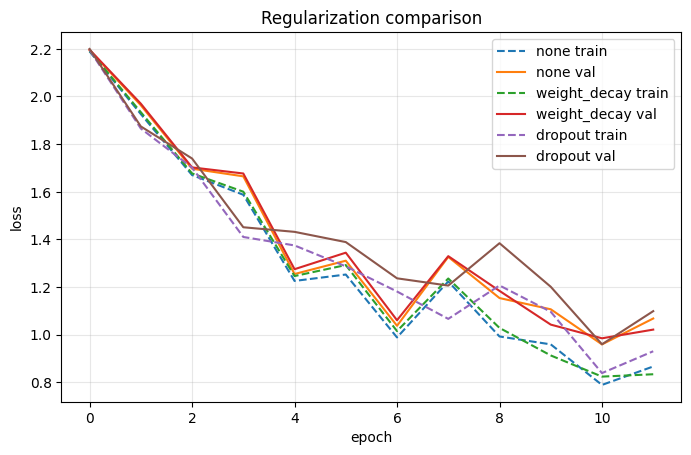

none         final_train_loss=0.8667, final_val_loss=1.0681
weight_decay final_train_loss=0.8341, final_val_loss=1.0215
dropout      final_train_loss=0.9306, final_val_loss=1.0990


In [3]:
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    if dropout == 1:
        return torch.zeros_like(X)
    mask = (torch.rand_like(X) > dropout).float()
    return mask * X / (1.0 - dropout)


def net_with_dropout(X, params, dropout=0.0, is_training=True):
    W1, b1, W2, b2 = params
    H = relu(torch.matmul(X, W1) + b1)
    H = dropout_layer(H, dropout, is_training)
    return torch.matmul(H, W2) + b2


def train_custom_mlp(config, train_subset=256, epochs=12):
    torch.manual_seed(7)
    params = init_mlp(num_hiddens=256)
    X_small, y_small = X_train[:train_subset], y_train[:train_subset]
    train_losses, val_losses = [], []
    batch_size = 64
    lr = 0.35
    for epoch in range(epochs):
        for Xb, yb in batch_iter(X_small, y_small, batch_size):
            logits = net_with_dropout(Xb, params, config["dropout"], is_training=True)
            loss = cross_entropy_with_softmax(logits, yb)
            loss.backward()
            sgd(params, lr, batch_size, weight_decay=config["weight_decay"])
        with torch.no_grad():
            train_loss = cross_entropy_with_softmax(
                net_with_dropout(X_small, params, config["dropout"], is_training=False), y_small
            ).item()
            val_loss = cross_entropy_with_softmax(
                net_with_dropout(X_val, params, config["dropout"], is_training=False), y_val
            ).item()
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    return train_losses, val_losses


configs = {
    "none": {"weight_decay": 0.0, "dropout": 0.0},
    "weight_decay": {"weight_decay": 0.01, "dropout": 0.0},
    "dropout": {"weight_decay": 0.0, "dropout": 0.5},
}

curves = {name: train_custom_mlp(cfg) for name, cfg in configs.items()}

plt.figure(figsize=(8, 4.8))
for name, (train_curve, val_curve) in curves.items():
    plt.plot(train_curve, linestyle="--", label=f"{name} train")
    plt.plot(val_curve, label=f"{name} val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Regularization comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for name, (train_curve, val_curve) in curves.items():
    print(f"{name:12s} final_train_loss={train_curve[-1]:.4f}, final_val_loss={val_curve[-1]:.4f}")

## 4 数值稳定性和激活函数

### 4.1 理论计算题

深层网络反向传播中会出现多层雅可比矩阵连乘：

$$
\prod_{i=t}^{d-1}\frac{\partial h_{i+1}}{\partial h_i}
$$

若每层矩阵的谱范数和激活函数导数的乘积长期大于 1，梯度范数会随深度近似指数增长，产生梯度爆炸；若长期小于 1，梯度会指数衰减，产生梯度消失。

Sigmoid 和 tanh 在饱和区导数接近 0，所以深层连乘容易让梯度变小。ReLU 在正区间导数为 1，避免了饱和区的大量小导数，因此能明显缓解梯度消失；但它仍需要合适的初始化来避免数值爆炸或神经元失活。

### 4.2 编程题：模拟数值不稳定并验证初始化策略

In [4]:
import torch.nn as nn


def build_deep_net(activation="sigmoid"):
    layers = []
    for i in range(20):
        layers.append(nn.Linear(256, 256))
        if activation == "sigmoid":
            layers.append(nn.Sigmoid())
        elif activation == "relu":
            layers.append(nn.ReLU())
        else:
            layers.append(nn.LeakyReLU(0.1))
    layers.append(nn.Linear(256, 10))
    return nn.Sequential(*layers)


def init_weights(model, mode, std=1.0):
    for m in model:
        if isinstance(m, nn.Linear):
            if mode == "normal":
                nn.init.normal_(m.weight, mean=0.0, std=std)
            elif mode == "xavier":
                nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)


def gradient_report(model):
    X = torch.randn(32, 256)
    y = torch.randint(0, 10, (32,))
    out = model(X)
    loss = nn.CrossEntropyLoss()(out, y)
    model.zero_grad()
    loss.backward()
    norms = [m.weight.grad.norm().item() for m in model if isinstance(m, nn.Linear)]
    has_bad_value = any((not np.isfinite(v)) for v in norms)
    print("first 5 gradient norms:", [f"{v:.3e}" for v in norms[:5]])
    print("last 5 gradient norms: ", [f"{v:.3e}" for v in norms[-5:]])
    print("min/max:", f"{min(norms):.3e}", f"{max(norms):.3e}", "has_nan_or_inf:", has_bad_value)
    return norms


print("Case 1: Sigmoid + normal std=0.1")
torch.manual_seed(0)
sigmoid_net = build_deep_net("sigmoid")
init_weights(sigmoid_net, "normal", std=0.1)
sigmoid_norms = gradient_report(sigmoid_net)

print("\nCase 2: ReLU + normal std=10")
torch.manual_seed(0)
exploding_net = build_deep_net("relu")
init_weights(exploding_net, "normal", std=10.0)
exploding_norms = gradient_report(exploding_net)

print("\nCase 3: LeakyReLU + Xavier")
torch.manual_seed(0)
stable_net = build_deep_net("leaky_relu")
init_weights(stable_net, "xavier")
stable_norms = gradient_report(stable_net)

Case 1: Sigmoid + normal std=0.1
first 5 gradient norms: ['1.774e-09', '4.203e-09', '1.194e-08', '3.543e-08', '1.002e-07']
last 5 gradient norms:  ['3.047e-02', '8.621e-02', '2.529e-01', '7.954e-01', '2.157e+00']
min/max: 1.774e-09 2.157e+00 has_nan_or_inf: False

Case 2: ReLU + normal std=10
first 5 gradient norms: ['nan', 'nan', 'nan', 'nan', 'nan']
last 5 gradient norms:  ['nan', 'nan', 'nan', 'nan', 'nan']
min/max: nan nan has_nan_or_inf: True

Case 3: LeakyReLU + Xavier
first 5 gradient norms: ['4.112e-03', '4.096e-03', '4.234e-03', '4.212e-03', '4.236e-03']
last 5 gradient norms:  ['4.450e-03', '4.684e-03', '4.559e-03', '4.508e-03', '3.169e-03']
min/max: 3.169e-03 4.901e-03 has_nan_or_inf: False


## 5 泛化表现、协变量偏移和对抗性数据

### 5.1 理论计算题

协变量偏移指训练环境和测试环境的输入分布不同，即 $p(x)\ne q(x)$，但标注规则不变，即 $p(y|x)=q(y|x)$。例如电商推荐中，训练数据主要来自老用户，测试时来了大量新用户，用户特征分布变了，但同样特征下的购买倾向规则仍近似一致。

标签偏移指类别比例不同，即 $p(y)\ne q(y)$，但每一类内部的特征分布基本不变，即 $p(x|y)=q(x|y)$。例如医院训练集中某疾病患者比例较高，真实筛查人群中该疾病比例较低，但患病者本身的检查指标分布没有明显变化。

二者都属于训练分布与测试分布不一致的问题；区别是协变量偏移主要变在输入 $x$ 的边缘分布，标签偏移主要变在标签 $y$ 的先验分布。

### 5.2 编程题：模拟协变量偏移与权重修正

baseline theta: [0.0131 2.0068]
weighted theta: [0.02   1.9933]
baseline test MSE: 0.010957
weighted test MSE: 0.01041
MSE improvement: 0.000547


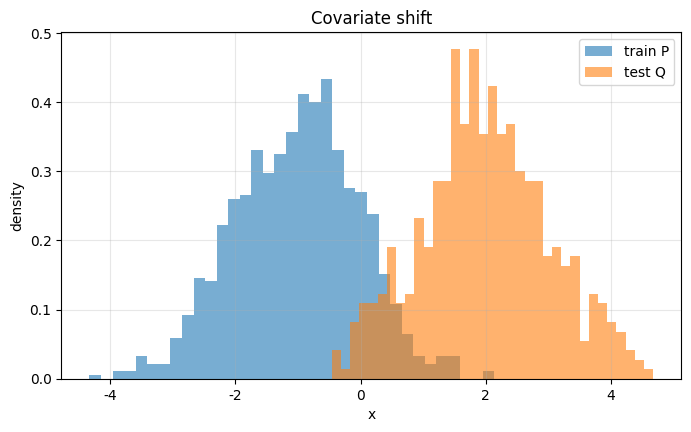

In [5]:
def fit_weighted_linear(x, y, sample_weight=None):
    X = np.c_[np.ones(len(x)), x.reshape(-1)]
    if sample_weight is None:
        theta = np.linalg.pinv(X.T @ X) @ (X.T @ y)
    else:
        w = sample_weight.reshape(-1, 1)
        theta = np.linalg.pinv(X.T @ (w * X)) @ (X.T @ (sample_weight * y))
    return theta


def predict_linear(theta, x):
    X = np.c_[np.ones(len(x)), x.reshape(-1)]
    return X @ theta


def train_domain_classifier(x_train, x_test, steps=2000, lr=0.1):
    X = np.vstack([x_train, x_test]).astype("float32")
    domain = np.r_[np.zeros(len(x_train)), np.ones(len(x_test))].astype("float32").reshape(-1, 1)
    mean, std = X.mean(), X.std()
    Xs = torch.tensor((X - mean) / std)
    d = torch.tensor(domain)
    torch.manual_seed(0)
    w = torch.zeros(1, 1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    for _ in range(steps):
        logits = Xs @ w + b
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, d)
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
            w.grad.zero_()
            b.grad.zero_()
    return w.detach(), b.detach(), mean, std


def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))


rng = np.random.default_rng(6)
x_train = rng.normal(-1, 1, 1000).reshape(-1, 1)
y_train = 2 * x_train.reshape(-1) + rng.normal(0, 0.1, 1000)
x_test = rng.normal(2, 1, 500).reshape(-1, 1)
y_test = 2 * x_test.reshape(-1) + rng.normal(0, 0.1, 500)

theta_base = fit_weighted_linear(x_train, y_train)
base_mse = mse(y_test, predict_linear(theta_base, x_test))

w_dom, b_dom, mean_dom, std_dom = train_domain_classifier(x_train, x_test)
train_scaled = torch.tensor(((x_train - mean_dom) / std_dom).astype("float32"))
p_test = torch.sigmoid(train_scaled @ w_dom + b_dom).numpy().reshape(-1)
p_train = 1.0 - p_test
weights = p_test / np.clip(p_train, 1e-6, None)
weights = np.clip(weights, 0, np.percentile(weights, 99))
weights = weights / weights.mean()

theta_weighted = fit_weighted_linear(x_train, y_train, weights)
weighted_mse = mse(y_test, predict_linear(theta_weighted, x_test))

print("baseline theta:", np.round(theta_base, 4))
print("weighted theta:", np.round(theta_weighted, 4))
print("baseline test MSE:", round(base_mse, 6))
print("weighted test MSE:", round(weighted_mse, 6))
print("MSE improvement:", round(base_mse - weighted_mse, 6))

plt.figure(figsize=(8, 4.5))
plt.hist(x_train.reshape(-1), bins=35, alpha=0.6, density=True, label="train P")
plt.hist(x_test.reshape(-1), bins=35, alpha=0.6, density=True, label="test Q")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Covariate shift")
plt.legend()
plt.grid(alpha=0.3)
plt.show()